In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random as rd
from scipy.integrate import odeint, solve_ivp
import cobra
plt.rcParams["figure.figsize"] = (9,7)
import os

## MODEL

In [2]:

# Switch from glucose to acetate consumers
def step_function_kga(A, G, beta_A, beta_G, kga):  
    wga = kga * (1 + np.tanh(beta_A * A - beta_G * G))
    return wga


# Switch from acetate to glucose consumers
def step_function_kag(G, A, beta_A, beta_G, kag):
    wag = kag * (1 - np.tanh(beta_A * A - beta_G * G))
    return wag


# Demographic noise
def add_noise(alpha, N):
    noise = alpha * N ** (1 / 2) * np.random.normal(loc=0.0, scale=1.0, size=None)
    return noise


# Parameter f determines the flux partition into fermentation and respiration
def get_f(G, Vg, Km_g, Yg, u_thr):
    # Fermentation activates when the glucose uptake is higher than the threshold (T. Hwa)
    if (Vg*G/(G+Km_g)) > u_thr:
        u_resp = u_thr
        u_f = (Vg*G/(G+Km_g) - u_thr)
    # Otherwise there is no overflow
    else:
        u_resp = (Vg*G/(G+Km_g))
        u_f = 0
    return u_resp, u_f


# Model equations
def chemostat(t,y, Va, Vg, Km_a, Km_g, Ya, Yg, Yg_ferm, A0, G0, D, alpha, beta_A,
              beta_G, kga, kag, u_thr, growth_rates_file, event=False):
    '''
    Parameters: 
        t: total time of simulation in hours (float)
        y: initial conditions of acetate population (g/l), glucose population (g/l)
           acetate (mM) and glucose (mM) (list)
        Va: maximum acetate uptake (mmol/gDW·h) (float)
        Vg: maximum glucose uptake (mmol/gDW·h) (float)
        Km_a: Michaelis Menten constant for acetate uptake (mM) (float)
        Km_g: Michaelis Menten constant for glucose uptake (mM) (float)
        Ya: yield of acetate respiration (float)
        Yg: yield of glucose respiration (float)
        Yg_ferm: yield of glucose fermentation (float)
        A0: Acetate concentration in the feed (mM) (float)
        G0: Glucose concentration in the feed (mM) (float)
        D: Dilution rate (h⁻¹) (float)
        alpha: magnitude of noise (float)
        beta_A: contribution of A to activate the switch (float)
        beta_G: contribution of G to activate the switch (float)
        kga: transition constant from glucose to acetate consumers (h⁻¹) (float)
        kag: transition constant from acetate to glucose consumers (h⁻¹) (float)
        u_thr: glucose uptake threshold to activate overflow (mmol/gDW·h) (float)
        event: activate or not the pulses events -- Default: change in the feed 
               (modify the code for different pulses) (Bool)    
    '''
    
    # initial conditiokns
    Na, Ng, A, G = y
    
    # To do: modify the code to customize the event
    if event==2:
        #if t > 23: 
        if t>10.4 and t<10.45:
            A0= 200/(D*10)*1000/59
            #A0 = 1*1000/59
            #A0 = 0
            #G0 = 6*1000/180
            #G0=1.3*1000/180
            #G0=0.5*1000/180
        #if t>14:
            #G0 = 0.5*1000/180
         #   A0 = 0
    if event==1:
        if t > 23: 
            G0=1*1000/180
            #G0=0.5*1000/180
        #if t>14:
            #G0 = 0.5*1000/180
         #   A0 = 0
    
    
    ## Evaluate growth rate: 
    if t in [3, 3.9, 4.83, 6.2]:
        avg_growht = (((Va * A) / (A + Km_a) * Ya* Na +  
                      (get_f(G, Vg, Km_g, Yg, u_thr)[0]*Yg+get_f(G, Vg, Km_g, Yg, u_thr)[1] * Yg_ferm)*Ng)/
                     (Na+Ng))

    ## Evaluate growth rate: 
    avg_growht = (((Va * A) / (A + Km_a) * Ya* Na +  
                      (get_f(G, Vg, Km_g, Yg, u_thr)[0]*Yg+get_f(G, Vg, Km_g, Yg, u_thr)[1] * Yg_ferm)*Ng)/
                     (Na+Ng))
    growth_rates_file.write(str(t) +'\t'+str(round(avg_growht-D,4))+'\n')
    
    if Na < 0.000001:
        Na = 0
    if Ng < 0.000001:
        Ng = 0
        
    
    # Model equations
    dydt = [
            # ACETATE POPULATION 
            (Va * A) / (A + Km_a) * Ya * Na                      # Growth on acetate
            + step_function_kga(A, G, beta_A, beta_G, kga) * Ng  # Switch from glu to ac
            - D * Na                                             # Dilution
            - step_function_kag(G, A, beta_A, beta_G, kag) * Na  # Switch from ac to glu
            + add_noise(alpha, Na),                              # Demographic noise
        
            # GLUCOSE POPULATION
            get_f(G, Vg, Km_g, Yg, u_thr)[0] * Yg * Ng             # Growth on glucose (respiration)
            + get_f(G, Vg, Km_g, Yg, u_thr)[1] * Yg_ferm * Ng      # Growth on glucose (fermentation)
            + step_function_kag(G, A, beta_A, beta_G, kag) * Na    # Switch from ac to glu
            - D * Ng                                               # Dilution
            - step_function_kga(A, G, beta_A, beta_G, kga) * Ng    # Switch from glu to ac
            + add_noise(alpha, Ng),                                # Demographic noise
        
            # ACETATE CONCENTRATION
            D * A0                                       # Input from the feed
            + get_f(G, Vg, Km_g, Yg, u_thr)[1] * Ng * 2  # Acetate production through fementation (stoich coef=2)
            - (Va * A) / (A + Km_a) * Na                 # Acetate consumption
            - D*A,                                       # Dilution
        
            # GLUCOSE CONCENTRATION
            D * G0                        # Input from the feed 
            - (Vg * G) / (G + Km_g) * Ng  # Glucose consumption
            - D*G                         # Dilution
            ]
    
    return dydt



def run_chemostat(D=0.1, total_t=None, A0=2, G0=4, plot=False, event=False, initial_od=0.01, 
                    fit_parameters = [0.014, 2.96, 350, 0.04, 10, 15, 0.08, 0.0026, 6.5, 0.017,
                                     0.087, 0.021], t_eval=None, noise=True, od_start_chemostat = 0.25):
    
    # Parameters of the model
    beta_A = fit_parameters[0]
    beta_G = fit_parameters[1]
    kga = fit_parameters[2]
    kag = fit_parameters[3]
    Va = fit_parameters[4]
    Vg = fit_parameters[5]
    Km_a = fit_parameters[6]
    Km_g = fit_parameters[7]
    u_thr = fit_parameters[8]
    Ya = fit_parameters[9]
    Yg = fit_parameters[10]
    Yg_ferm = fit_parameters[11] 
    
    # Initial population (equally distributed into ac and glucose consumers)
    # Conversion factor from OD to g/l: 0.35
    y0 = [initial_od*0.5*0.35, initial_od*0.5*0.35, A0, G0]
    
    # Fixed parameters
    D0 = D  
    if noise:
        alpha = 0.25
    else:
        alpha = 0


    # Time span for the integration
    t_start = 0.0
    if total_t == None:
        total_t = max(t_eval)
    t_end = total_t
    
    # Fixed time step size
    time_step = 0.002
    
    # Create a sequence of time points with the fixed time step
    if t_eval == None:
        t_eval = np.arange(t_start, t_end + time_step, time_step)
    else:
        t_eval = t_eval + list(np.arange(t_start, t_end + time_step, time_step) )
        t_eval = sorted(list(set(t_eval)))
    #print(t_eval)
    
    # Initialize the array to store the solution
    y_values = []
    y_values.append(y0)
    
    # Perform the integration using the Forward Euler method
    # Initialize with a batch culture
    growth_rates_file = 'growth_vs_t.dat'
    growth_rates_file = open(growth_rates_file, mode='w')
    chemostat_on = False
    for i in range(1, len(t_eval)):
        t = t_eval[i - 1]
        y = y_values[i - 1]
        # batch culture until OD reaches 0.2
        if (y[0]+y[1])/0.35< od_start_chemostat and not chemostat_on:
            D = 0
        # activate chemostat if OD>0.2
        else:
            chemostat_on = True
            D = D0
        # solve equations of the model
        y_2 = chemostat(t, y, Va, Vg, Km_a, Km_g, Ya, Yg, Yg_ferm, A0, G0,
                        D, alpha, beta_A, beta_G,kga, kag, u_thr, growth_rates_file, event)
        
        if i>1:
            time_step = t-t_eval[i-2]
        else:
            time_step = t-0
        
        y_values.append([y[j] + time_step * y_2[j] for j in range(0,4)])
    growth_rates_file.close()
    
    # Plot solution
    if plot: 
        plt.plot(t_eval, [point[0] for point in y_values], 'b', label='Na')
        plt.plot(t_eval, [point[1] for point in y_values], 'g', label='Ng')
        plt.plot(t_eval, [point[0]+point[1] for point in y_values], 'black', label='Total')
        plt.plot(t_eval, [point[2]/1000*59 for point in y_values], 'r', label='A')
        plt.plot(t_eval, [point[3]/1000*180 for point in y_values], 'y', label='G')
        plt.legend(loc='upper right', fontsize=15)
        plt.xlabel('t')
        plt.ylabel('(g/l)',fontsize=20)
        plt.xlabel('time (h)', fontsize=20)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.show()
    
    # Store solution in a DataFrame
    solution = {'t':t_eval, 
                'Na': [point[0] for point in y_values], 
                'Ng': [point[1] for point in y_values],
                'Total': [point[0] + point[1] for point in y_values],
                'A': [point[2] for point in y_values],
                'G': [point[3] for point in y_values]}
    solution_df = pd.DataFrame(solution)
            
    return t_eval, y_values, solution_df


def calculate_avg_curve(data):
    stats = {'t':list(data.t), 'avg':[], 'sd':[]}
    
    for t in data.iterrows():
        stats['avg'].append(np.mean(t[1][1:]))
        stats['sd'].append(np.std(t[1][1:]))
    
    avg_df = pd.DataFrame(stats)

    
    return avg_df


import numpy as np
import matplotlib.pyplot as plt

def get_growth_from_OD(time, od, a=100):
    """
    Compute growth rate from OD measurements using moving average smoothing.
    
    Parameters
    ----------
    time : array-like
        Time points
    od : array-like
        Optical density values
    a : int
        Window size for moving average (default = 100)
    
    Returns
    -------
    time : ndarray
        Time points (same length as input)
    GR1 : ndarray
        Smoothed growth rate
    """

    time = np.array(time)
    od = np.array(od)

    # Time step
    delta_t = np.mean(np.diff(time))

    # Log-transformed signal
    S = np.log(od * 0.35)

    # Moving average (same length as input)
    kernel = np.ones(a) / a
    S1 = np.convolve(S, kernel, mode="same")

    # Growth rate (derivative)
    GR = np.gradient(S1, delta_t)

    # Smooth growth rate
    GR1 = np.convolve(GR, kernel, mode="same")


    return time, GR1


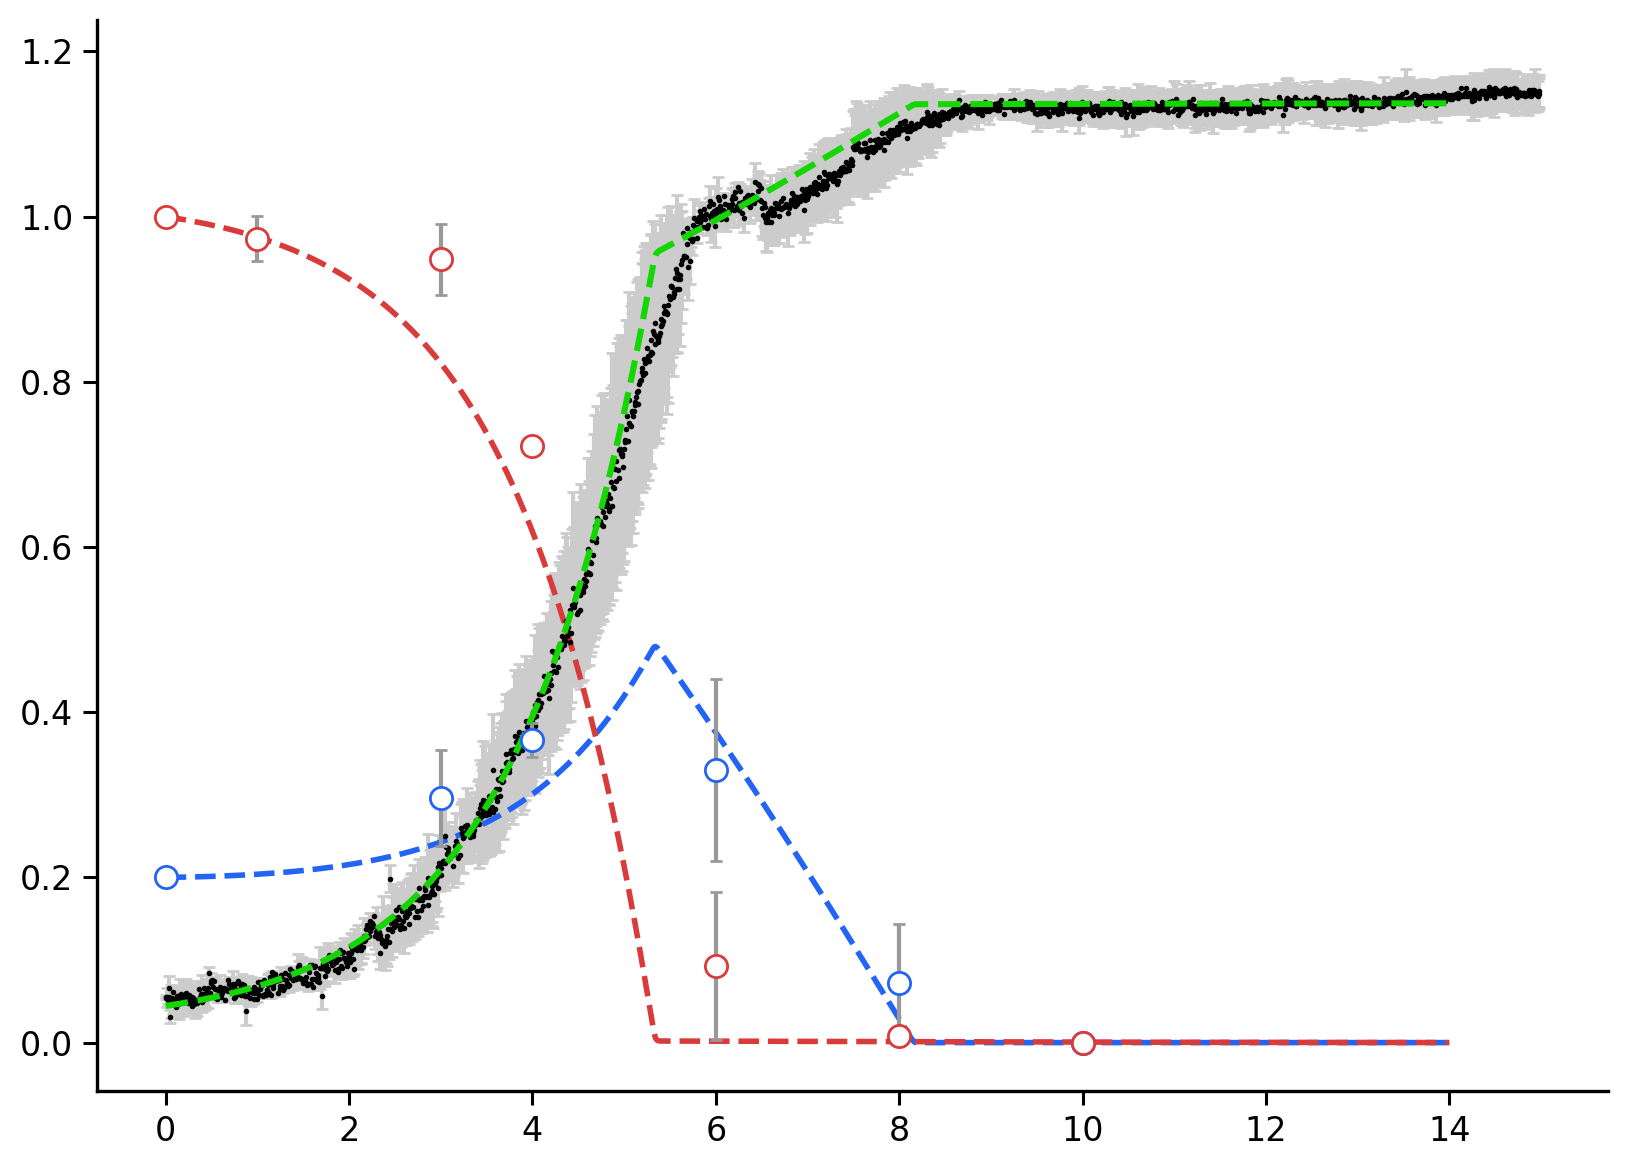

In [9]:
data = pd.read_csv('Ecoli_GlcAct_OD_RawData_012925/01292025.dat', sep='\t')

avg_df = calculate_avg_curve(data[['t', 'OD5', 'OD8']])
ini = 0
fin = -1

growth_df = {}
time_corrected, GR = get_growth_from_OD(np.array(avg_df.t[ini:fin]), np.array(avg_df['avg'][ini:fin]))
if 't' not in growth_df.keys():
    growth_df['t'] = time_corrected
growth_df['avg'] = GR
growth_df = pd.DataFrame(growth_df)

conc = pd.read_csv('Ecoli_GlcAct_OD_RawData_012925/HPLC_Ecoli_GlcAct_Glc_012925/conc.dat', sep='\t')

time = conc.t
conc_avg_a = [np.mean([conc[conc.t==i]['OD5A'], conc[conc.t==i]['OD8A']]) for i in time if i!=1]
conc_sd_a = [np.std([conc[conc.t==i]['OD5A'], conc[conc.t==i]['OD8A']]) for i in time if i!=1]
for i,s in enumerate(conc_sd_a):
    if s==0:
        conc_sd_a[i] = 0.0001
conc_avg_g = [np.mean([conc[conc.t==i]['OD5G'], conc[conc.t==i]['OD8G']]) for i in time]
conc_sd_g = [np.std([conc[conc.t==i]['OD5G'], conc[conc.t==i]['OD8G']]) for i in time]
#conc_avg_g[1] = 0.99
conc_avg_g[2] = conc_avg_g[2]#*0.95
for i,s in enumerate(conc_sd_g):
    if s==0:
        conc_sd_g[i] = 0.0001
        
 

In [7]:
from scipy.interpolate import interp1d

def objective_function(params, A0, G0, D, w_od=10.0, w_conc=1.0):
    
    t, sol, _ = run_chemostat(
        D=D,
        total_t=14,
        A0=A0,
        G0=G0,
        event=False,
        plot=False,
        initial_od=avg_df['avg'][ini]*0.8,
        fit_parameters=params,
        t_eval=[0],
        noise=False
    )

    t = np.array(t)

    # ===== MODEL OUTPUTS =====
    od_model = np.array([(j[0] + j[1]) / 0.35 for j in sol])
    ace_model = np.array([j[2] / 1000 * 59 for j in sol])
    glc_model = np.array([j[3] / 1000 * 180 for j in sol])

    # ===== OD =====
    t_exp_od = np.array(avg_df.t[ini:]) - avg_df.t[ini]
    od_exp = np.array(avg_df.avg[ini:])
    od_sd = np.array(avg_df.sd[ini:])

    f_od = interp1d(t, od_model, bounds_error=False, fill_value="extrapolate")
    od_pred = f_od(t_exp_od)

    chi_od = np.sum(((od_exp - od_pred) / od_sd)**2)

    # ===== ACETATE =====
    t_exp_a = np.array([i for i in conc.t if i != 1])
    f_ace = interp1d(t, ace_model, bounds_error=False, fill_value="extrapolate")
    ace_pred = f_ace(t_exp_a)

    chi_ace = np.sum(((np.array(conc_avg_a) - ace_pred) / np.array(conc_sd_a))**2)

    # ===== GLUCOSE =====
    t_exp_g = np.array(conc.t)
    f_glc = interp1d(t, glc_model, bounds_error=False, fill_value="extrapolate")
    glc_pred = f_glc(t_exp_g)

    chi_glc = np.sum(((np.array(conc_avg_g) - glc_pred) / np.array(conc_sd_g))**2)

    return w_od * chi_od + w_conc * (chi_ace + chi_glc)



def propose_params(params, bounds=None, scale=0.3):
    new_params = []

    for i, p in enumerate(params):
        if i not in [4,5]:
            if p <= 0:
                new_p = p + scale * np.random.randn()
            else:
                factor = np.exp(scale * np.random.randn())
                new_p = p * factor
    
            # Apply bounds if provided
            if bounds is not None:
                new_p = np.clip(new_p, bounds[i][0], bounds[i][1])
    
            new_params.append(new_p)
        else: 
            new_params.append(p)

    return np.array(new_params)

import random as rd



def simulated_annealing(
    initial_params,
    T_initial,
    cooling_rate,
    n_iterations,
    bounds=None
):
    A0 = 0.2 * 1000 / 59
    G0 = 1.0 * 1000 / 180
    D = 0

    current_params = np.array(initial_params)
    current_cost = objective_function(current_params, A0, G0, D)

    best_params = np.copy(current_params)
    best_cost = current_cost

    T = T_initial
    scale = 0.3  # initial step size

    for i in range(n_iterations):

        # NEW perturbation
        new_params = propose_params(current_params, bounds, scale)

        # Compute cost
        new_cost = objective_function(new_params, A0, G0, D)
        new_cost += cost_priors(initial_params, new_params)

        # Acceptance
        if new_cost < current_cost:
            accept = True
        else:
            prob = np.exp((current_cost - new_cost) / T)
            accept = rd.random() < prob

        if accept:
            current_params = new_params
            current_cost = new_cost

            if new_cost < best_cost:
                best_params = np.copy(new_params)
                best_cost = new_cost

        # Cooling
        T *= cooling_rate
        scale *= 0.995  # gradually reduce step size

        if i % 50 == 0:
            print(f"Iter {i} | Cost: {current_cost:.2f} | Best: {best_cost:.2f}")
            print(best_params)

    return best_params, best_cost

bounds = [
    (1e-4, 100),
    (1e-4, 100),
    (1e-4, 100),
    (1e-4, 100),
    (1, 50),
    (1, 50),
    (0.01, 0.1),
    (0.001, 0.01),
    (6, 8),
    (0.004, 0.015),
    (0.04, 0.15),
    (0.01, 0.04)
]



def cost_priors(initial_params, new_params):
    cost_priors = 0
    for i in range(9,12):
        cost_priors += float((initial_params[i]-new_params[i])**2)*50
    return cost_priors


# Initial guess for parameters
initial_params =[6.99528217e-03, 6.40419375e+00, 7.91477552e+01, 5.14863340e-02,
       8.00000000e+00, 1.20000000e+01, 1.01019216e-02, 2.92284662e-03,
       7.46289510e+00, 1.06684992e-02, 7.33686721e-02, 1.64204776e-02] # Initial guess for parameters


best_params, best_cost = simulated_annealing(
    initial_params=initial_params,
    T_initial=10.0,
    cooling_rate=0.995,
    n_iterations=2000,
    bounds=bounds
)

print("Best parameters found:", best_params)
print("Best cost:", best_cost)

Iter 0 | Cost: 73148888.07 | Best: 73148888.07
[6.99528217e-03 6.40419375e+00 7.91477552e+01 5.14863340e-02
 8.00000000e+00 1.20000000e+01 1.01019216e-02 2.92284662e-03
 7.46289510e+00 1.06684992e-02 7.33686721e-02 1.64204776e-02]
Iter 50 | Cost: 1567271.39 | Best: 1567271.39
[1.17504758e-02 5.83589300e+00 9.66354005e+01 3.71375430e-02
 8.00000000e+00 1.20000000e+01 1.00000000e-02 3.74366170e-03
 6.83702981e+00 8.03669089e-03 7.21338726e-02 4.00000000e-02]
Iter 100 | Cost: 845876.24 | Best: 845876.24
[8.89837129e-03 1.32101608e+01 7.93396970e+01 3.50404126e-02
 8.00000000e+00 1.20000000e+01 1.61578602e-02 2.49082478e-03
 6.29758744e+00 7.39390143e-03 7.27650336e-02 4.00000000e-02]
Iter 150 | Cost: 845876.24 | Best: 845876.24
[8.89837129e-03 1.32101608e+01 7.93396970e+01 3.50404126e-02
 8.00000000e+00 1.20000000e+01 1.61578602e-02 2.49082478e-03
 6.29758744e+00 7.39390143e-03 7.27650336e-02 4.00000000e-02]
Iter 200 | Cost: 845876.24 | Best: 845876.24
[8.89837129e-03 1.32101608e+01 7.933

Iter 1800 | Cost: 822131.90 | Best: 822131.90
[9.01013360e-03 1.34132980e+01 8.20456209e+01 3.37073317e-02
 8.00000000e+00 1.20000000e+01 1.54227986e-02 2.48693681e-03
 6.45827758e+00 7.67203964e-03 7.26874956e-02 3.88116670e-02]
Iter 1850 | Cost: 822130.10 | Best: 822130.10
[9.01064017e-03 1.34140364e+01 8.20457015e+01 3.37092516e-02
 8.00000000e+00 1.20000000e+01 1.54219806e-02 2.48679442e-03
 6.45897919e+00 7.67216523e-03 7.26892043e-02 3.88062416e-02]
Iter 1900 | Cost: 822126.86 | Best: 822126.86
[9.01099854e-03 1.34136062e+01 8.20422057e+01 3.37044822e-02
 8.00000000e+00 1.20000000e+01 1.54233328e-02 2.48670115e-03
 6.45948473e+00 7.67330632e-03 7.26838537e-02 3.88091711e-02]
Iter 1950 | Cost: 822125.32 | Best: 822125.32
[9.01092486e-03 1.34133621e+01 8.20458157e+01 3.37049878e-02
 8.00000000e+00 1.20000000e+01 1.54236066e-02 2.48663865e-03
 6.45974842e+00 7.67370767e-03 7.26831809e-02 3.88074569e-02]
Best parameters found: [9.01120637e-03 1.34130936e+01 8.20406849e+01 3.37028851e

In [8]:
       

        # ===============================
# Imports
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ===============================
# Global paper-style settings
# ===============================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,

    "axes.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,

    "legend.frameon": False,
    "legend.fontsize": 10,

    "figure.figsize": (8.3, 6),
    "savefig.dpi": 200,
    "figure.dpi":200
    
})


# ===============================
# Parameters & initial conditions
# ===============================
D = 0

A0 = 0.2 * 1000 / 59
G0 = 1.0 * 1000 / 180

ini = 0
#dif_t = data.t[ini] #- 0.05

# GLC replicates: OD4, OD9, OD12, OD13


# ===============================
# Colors (muted, paper-safe)
# ===============================
COLOR_GLU = "#D93B3B"     # stronger red (was #B24745)
COLOR_ACE = "#2264F5"     # stronger blue (was #3A6EA5)
COLOR_GROWTH = "0.35"     # darker grey (was 0.5)
COLOR_OD = "#14D602"      # more vivid light blue for OD model

# ===============================
# Experimental data
# ===============================
# Cell density (EXP)
plt.errorbar(
    np.array(avg_df.t[ini:]) - avg_df.t[ini],
    np.array(avg_df.avg[ini:]),# * 0.35,
    yerr=np.array(avg_df.sd[ini:]),# * 0.35,
    fmt='o',
    ms=1,
    mfc='white',
    mec='black',
    ecolor='0.8',
    capsize=2,
    label='OD (exp)'
)




# ===============================
# Metabolites – experimental
# ===============================
# Acetate (EXP)
t_vals = np.array([i for i in conc.t if i!=1])
plt.errorbar(
    np.array(t_vals),
    conc_avg_a,
    yerr=conc_sd_a,
    fmt='o',
    ms=8,
    mfc='white',
    mec=COLOR_ACE,
    ecolor='0.6',
    capsize=2,
    zorder=10,
    label='Acetate (exp)'
)

t_vals = np.array(conc.t)
# Glucose (EXP)
plt.errorbar(
    np.array(t_vals),
    conc_avg_g,
    yerr=conc_sd_g,
    fmt='o',
    ms=8,
    mfc='white',
    mec=COLOR_GLU,
    ecolor='0.6',
    capsize=2,
    zorder=10,
    label='Glucose (exp)'
)


t_ini=0

# ===============================
# Best-fit model parameters
# ===============================
old_params = [
    0.010110606566529,
    5.5975873182447606,
    8.08317435379539,
    0.02,
    8,
    12,
    0.06961391372173296,
    0.0042823295412901105,
    7,
    0.008,
    0.08045294877173,
    0.024072221913522672
]



best_params = [9.01120637e-03, 1.34130936e+01, 8.20406849e+01, 3.37028851e-02,
       8.00000000e+00, 1.20000000e+01, 1.54235139e-02, 2.48649488e-03,
       6.46017956e+00, 7.67419923e-03, 7.26812224e-02, 3.88069973e-02]
# ===============================
# Run chemostat model
# ===============================
t, sol, y_model_df = run_chemostat(
    D=D,
    total_t=14,
    A0=A0,
    G0=G0,
    event=False,
    plot=False,
    initial_od=avg_df['avg'][ini]*0.8,
    fit_parameters=best_params,
    t_eval=[0],
    noise=False
)

growth_model = pd.read_csv('growth_vs_t.dat', sep='\t', header=None)

# ===============================
# Model outputs
# ===============================
# Cell density (MODEL)
plt.plot(
    np.array(t)+t_ini,
    [(j[0] + j[1])/0.35 for j in sol],
    color=COLOR_OD,
    lw=2.2,
    label='OD (model)',
    linestyle='dashed',
    zorder=10
)


# Metabolite concentrations (MODEL)
plt.plot(
    np.array(t)+t_ini,
    [j[2] / 1000 * 59 for j in sol],
    color=COLOR_ACE,
    lw=2,
    linestyle='dashed',
    label='Acetate (model)'
)

plt.plot(
    np.array(t)+t_ini,
    [j[3] / 1000 * 180 for j in sol],
    color=COLOR_GLU,
    lw=2,
    linestyle='dashed',
    label='Glucose (model)'
)


plt.tight_layout()
plt.savefig("chemostat_figure.png", bbox_inches="tight")
plt.show()

array([9.01120637e-03, 1.34130936e+01, 8.20406849e+01, 3.37028851e-02,
       8.00000000e+00, 1.20000000e+01, 1.54235139e-02, 2.48649488e-03,
       6.46017956e+00, 7.67419923e-03, 7.26812224e-02, 3.88069973e-02])